# 📓 Step 06 — Contextual Representation

> *"SecurityBERT utilizes a transformer-based architecture consisting of multiple*
> *encoder layers. Each encoder layer comprises multi-head self-attention mechanisms*
> *and position-wise feed-forward neural networks."*
> — SecurityBERT Paper, Section III-F

---

## 🎯 Objective
Implement and deeply inspect the **contextual representation** produced by
SecurityBERT's encoder layers. This notebook:
1. Implements the **multi-head self-attention** mechanism (Equation 3)
2. Implements each sub-layer of the **BERT Encoder** (Figure 5)
3. Verifies contextual representations are **attack-type aware**
4. Visualizes attention patterns across PPFLE token sequences
5. Prepares the full encoder pipeline for training in Notebook 07

## 📋 Notebook Roadmap

| Step | Task | Output |
|------|------|--------|
| 1 | Imports & Setup | — |
| 2 | Load model + tokenized data | SecurityBERT, tensors |
| 3 | Self-Attention mechanism (Equation 3) | `SecurityBERTSelfAttention` |
| 4 | BERT Encoder sub-layers (Figure 5) | All sub-layer classes |
| 5 | Full Encoder stack (4 layers) | `SecurityBERTEncoder` |
| 6 | Contextual representation forward pass | Hidden states |
| 7 | Attention weight extraction & analysis | Attention maps |
| 8 | Contextual representation visualization | Heatmaps, PCA |
| 9 | Compare pre vs post encoder representations | Analysis |
| 10 | Save encoder outputs | `contextual_repr.pt` |

---

## 🔬 Core Equation — Self-Attention (Paper Equation 3)

```
Attention(Q, K, V) = σ( Q·Kᵀ / √dₖ ) · V
```

Where:
- **Q** = Query matrix  `(batch, heads, seq, head_dim)`
- **K** = Key matrix    `(batch, heads, seq, head_dim)`
- **V** = Value matrix  `(batch, heads, seq, head_dim)`
- **dₖ** = head dimension = hidden_size / num_heads = 128 / 4 = **32**
- **σ** = Softmax function
- **T** = Transpose operation

**Why self-attention for PPFLE data?**
```
Each MD5 token = one hashed feature (e.g. H(TCP.DSTPORT$443))
Self-attention lets SecurityBERT learn:
  "When TCP.DSTPORT=443 AND HTTP.METHOD=GET appear together
   → this combination signals an HTTP flood attack"
The model captures CROSS-FEATURE relationships automatically.
```

## 🧱 Step 1 — Imports & Setup

In [15]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
import math
import json
import time
from pathlib import Path

# ── Data ──────────────────────────────────────────────────────────────────────
import numpy as np

# ── Deep Learning ─────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# ── Transformers ──────────────────────────────────────────────────────────────
from transformers import BertConfig, BertModel

# ── ML utilities ──────────────────────────────────────────────────────────────
from sklearn.decomposition import PCA

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Plot theme ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#0f0f1a',
    'axes.facecolor'   : '#16162a',
    'axes.edgecolor'   : '#444477',
    'axes.labelcolor'  : '#ccccff',
    'xtick.color'      : '#aaaacc',
    'ytick.color'      : '#aaaacc',
    'text.color'       : '#e0e0ff',
    'grid.color'       : '#2a2a4a',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 14,
    'axes.labelsize'   : 11,
    'legend.facecolor' : '#1a1a2e',
    'legend.edgecolor' : '#444477',
})

ACCENT  = '#7c6cfa'
GREEN   = '#4ecca3'
RED     = '#fc5c65'
YELLOW  = '#f7b731'
PALETTE = [
    '#7c6cfa', '#4ecca3', '#f7b731', '#fc5c65', '#45aaf2',
    '#fd9644', '#26de81', '#a55eea', '#2bcbba', '#eb3b5a',
    '#20bf6b', '#0fb9b1', '#8854d0', '#4b6584', '#778ca3'
]

# ── Project paths ─────────────────────────────────────────────────────────────
BASE_DIR   = Path('..')
PROC_DIR   = BASE_DIR / 'data'    / 'processed'
CKPT_DIR   = BASE_DIR / 'checkpoints'
OUTPUT_DIR = BASE_DIR / 'outputs' / 'figures' / 'N6'

INPUT_DATA   = PROC_DIR / 'tokenized_sequences.pt'
INPUT_CKPT   = CKPT_DIR / 'securitybert_init.pt'
OUTPUT_PATH  = PROC_DIR / 'contextual_repr.pt'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Paper constants ────────────────────────────────────────────────────────────
VOCAB_SIZE          = 5_000
HIDDEN_SIZE         = 128
NUM_HIDDEN_LAYERS   = 2
NUM_ATTENTION_HEADS = 4
INTERMEDIATE_SIZE   = 512
MAX_POSITION_EMB    = 512
DROPOUT_PROB        = 0.1
NUM_CLASSES         = 15
HEAD_DIM            = HIDDEN_SIZE // NUM_ATTENTION_HEADS  # 128/4 = 32
RANDOM_STATE        = 42

print('✅ Environment ready.')
print(f'   PyTorch   : {torch.__version__}')
print(f'   Device    : {DEVICE}')
print()
print('📐 Self-Attention dimensions (Equation 3):')
print(f'   hidden_size         : {HIDDEN_SIZE}')
print(f'   num_attention_heads : {NUM_ATTENTION_HEADS}')
print(f'   head_dim (dₖ)       : {HEAD_DIM}   (= {HIDDEN_SIZE}/{NUM_ATTENTION_HEADS})')
print(f'   scale factor (√dₖ)  : {math.sqrt(HEAD_DIM):.4f}')

✅ Environment ready.
   PyTorch   : 2.12.0.dev20260402+cu128
   Device    : cuda

📐 Self-Attention dimensions (Equation 3):
   hidden_size         : 128
   num_attention_heads : 4
   head_dim (dₖ)       : 32   (= 128/4)
   scale factor (√dₖ)  : 5.6569


## 📂 Step 2 — Load Model & Tokenized Data

In [16]:
# ── Load tokenized data ───────────────────────────────────────────────────────
assert INPUT_DATA.exists(), (
    f'❌ File not found: {INPUT_DATA}\n'
    f'   Run Notebook 04 (BBPE Tokenizer) first.'
)
assert INPUT_CKPT.exists(), (
    f'❌ File not found: {INPUT_CKPT}\n'
    f'   Run Notebook 05 (SecurityBERT Embedding) first.'
)

print('📁 Loading tokenized dataset …')
data       = torch.load(INPUT_DATA, weights_only=False)
input_ids  = data['input_ids'].long()
attn_masks = data['attention_mask'].long()
labels     = data['labels'].long()
label_map  = data['label_map']

print(f'✅ Loaded:')
print(f'   input_ids    : {tuple(input_ids.shape)}')
print(f'   attn_masks   : {tuple(attn_masks.shape)}')
print(f'   labels       : {tuple(labels.shape)}')
print(f'   num_classes  : {len(label_map)}')

# ── Load model config ─────────────────────────────────────────────────────────
print(f'\n📁 Loading SecurityBERT config …')
ckpt   = torch.load(INPUT_CKPT, weights_only=False)
config = BertConfig(**ckpt['config'])

print(f'✅ Config loaded:')
print(f'   hidden_size         : {config.hidden_size}')
print(f'   num_hidden_layers   : {config.num_hidden_layers}')
print(f'   num_attention_heads : {config.num_attention_heads}')
print(f'   intermediate_size   : {config.intermediate_size}')

📁 Loading tokenized dataset …
✅ Loaded:
   input_ids    : (2218386, 512)
   attn_masks   : (2218386, 512)
   labels       : (2218386,)
   num_classes  : 15

📁 Loading SecurityBERT config …
✅ Config loaded:
   hidden_size         : 128
   num_hidden_layers   : 2
   num_attention_heads : 4
   intermediate_size   : 512


## 🔍 Step 3 — Multi-Head Self-Attention (Paper Equation 3)

The paper defines self-attention as:

```
Attention(Q, K, V) = σ( Q·Kᵀ / √dₖ ) · V        ... (3)
```

**Multi-Head extension:**
```
MultiHead(X) = Concat(head_1, ..., head_h) · Wᴼ

where head_i = Attention(X·Wᵢᴼ, X·Wᵢᴷ, X·Wᵢᵛ)
```

**SecurityBERT dimensions (Figure 5):**
```
Q, K, V projections : Linear(128 → 128)   ← in_features=128, out_features=128
Number of heads     : 4
Head dimension dₖ   : 128 / 4 = 32
Scale factor √dₖ    : √32 ≈ 5.657
Dropout             : Dropout(p=0.1)       ← after softmax scores
```

In [17]:
class SecurityBERTSelfAttention(nn.Module):
    """
    Multi-Head Self-Attention — Paper Equation (3) + Figure 5.

    Attention(Q, K, V) = σ( Q·Kᵀ / √dₖ ) · V

    SecurityBERT parameters (Figure 5):
        Q: Linear(128 → 128)
        K: Linear(128 → 128)
        V: Linear(128 → 128)
        num_heads = 4
        head_dim  = 32  (dₖ = 128/4)
        Dropout(p=0.1)
    """

    def __init__(self, config: BertConfig):
        super().__init__()

        assert config.hidden_size % config.num_attention_heads == 0, \
            f'hidden_size {config.hidden_size} not divisible by ' \
            f'num_heads {config.num_attention_heads}'

        self.num_heads  = config.num_attention_heads   # 4
        self.head_dim   = config.hidden_size // self.num_heads  # 32
        self.hidden_size= config.hidden_size           # 128

        # ── Q, K, V linear projections (Figure 5) ────────────────────────────
        # Each: Linear(in_features=128, out_features=128, bias=True)
        self.query   = nn.Linear(config.hidden_size, config.hidden_size)
        self.key     = nn.Linear(config.hidden_size, config.hidden_size)
        self.value   = nn.Linear(config.hidden_size, config.hidden_size)

        # ── Dropout after attention scores (Figure 5) ─────────────────────────
        self.dropout = nn.Dropout(config.attention_probs_dropout_prob)

    def split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """
        Reshape for multi-head attention.
        (batch, seq, hidden) → (batch, heads, seq, head_dim)
        """
        B, S, _ = x.size()
        x = x.view(B, S, self.num_heads, self.head_dim)
        return x.permute(0, 2, 1, 3)   # (B, heads, S, head_dim)

    def forward(
        self,
        hidden_states  : torch.Tensor,
        attention_mask : torch.Tensor = None,
        output_attentions: bool = False,
    ) -> tuple:
        """
        Parameters
        ----------
        hidden_states    : (batch, seq_len, hidden_size)  — input embeddings
        attention_mask   : (batch, 1, 1, seq_len)         — extended mask
        output_attentions: bool — whether to return attention weights

        Returns
        -------
        context_layer    : (batch, seq_len, hidden_size)
        attention_probs  : (batch, heads, seq, seq)  if output_attentions=True
        """
        B, S, _= hidden_states.size()

        # ── Linear projections: Q, K, V ───────────────────────────────────────
        Q = self.query(hidden_states)   # (B, S, 128)
        K = self.key(hidden_states)     # (B, S, 128)
        V = self.value(hidden_states)   # (B, S, 128)

        # ── Split into heads ──────────────────────────────────────────────────
        Q = self.split_heads(Q)   # (B, 4, S, 32)
        K = self.split_heads(K)   # (B, 4, S, 32)
        V = self.split_heads(V)   # (B, 4, S, 32)

        # ── Scaled dot-product attention — Equation (3) ───────────────────────
        # Q · Kᵀ  →  (B, 4, S, S)
        scale         = math.sqrt(self.head_dim)               # √dₖ = √32
        attention_scores = torch.matmul(Q, K.transpose(-1, -2)) / scale

        # Apply attention mask (0 for real tokens, large negative for padding)
        if attention_mask is not None:
            attention_scores = attention_scores + attention_mask

        # σ(·) — softmax over last dimension (key positions)
        attention_probs = F.softmax(attention_scores, dim=-1)  # (B, 4, S, S)
        attention_probs = self.dropout(attention_probs)        # Dropout(p=0.1)

        # Weighted sum over Values:  σ(QKᵀ/√dₖ) · V
        context = torch.matmul(attention_probs, V)             # (B, 4, S, 32)

        # ── Merge heads back ──────────────────────────────────────────────────
        # (B, 4, S, 32) → (B, S, 4, 32) → (B, S, 128)
        context = context.permute(0, 2, 1, 3).contiguous()
        context = context.view(B, S, self.hidden_size)         # (B, S, 128)

        if output_attentions:
            return context, attention_probs
        return context, None


# ── Unit test — verify shapes ──────────────────────────────────────────────────
attn_layer  = SecurityBERTSelfAttention(config)
dummy_input = torch.randn(2, 10, HIDDEN_SIZE)   # batch=2, seq=10, hidden=128
ctx, probs  = attn_layer(dummy_input, output_attentions=True)

print('✅ SecurityBERTSelfAttention defined and tested.')
print()
print('📐 Self-Attention (Paper Equation 3):')
print(f'   Q projection : Linear({HIDDEN_SIZE} → {HIDDEN_SIZE})')
print(f'   K projection : Linear({HIDDEN_SIZE} → {HIDDEN_SIZE})')
print(f'   V projection : Linear({HIDDEN_SIZE} → {HIDDEN_SIZE})')
print(f'   Scale (√dₖ)  : √{HEAD_DIM} = {math.sqrt(HEAD_DIM):.4f}')
print(f'   Dropout      : p={DROPOUT_PROB}')
print()
print('📤 Shape test:')
print(f'   Input  : {tuple(dummy_input.shape)}  (batch=2, seq=10, hidden=128)')
print(f'   Output : {tuple(ctx.shape)}           (batch=2, seq=10, hidden=128)')
print(f'   Attn   : {tuple(probs.shape)}    (batch=2, heads=4, seq=10, seq=10)')

✅ SecurityBERTSelfAttention defined and tested.

📐 Self-Attention (Paper Equation 3):
   Q projection : Linear(128 → 128)
   K projection : Linear(128 → 128)
   V projection : Linear(128 → 128)
   Scale (√dₖ)  : √32 = 5.6569
   Dropout      : p=0.1

📤 Shape test:
   Input  : (2, 10, 128)  (batch=2, seq=10, hidden=128)
   Output : (2, 10, 128)           (batch=2, seq=10, hidden=128)
   Attn   : (2, 4, 10, 10)    (batch=2, heads=4, seq=10, seq=10)


## 🏗️ Step 4 — BERT Encoder Sub-layers (Paper Figure 5)

Each of the **4 encoder layers** in SecurityBERT contains these sub-layers:

```
BertLayer:
├── BertAttention
│   ├── BertSelfAttention (Q, K, V + scaled dot-product)
│   └── BertSelfOutput
│       ├── Linear(128 → 128)
│       ├── Dropout(p=0.1)
│       └── LayerNorm(128, eps=1e-12)   ← residual connection + LN
│
├── BertIntermediate
│   ├── Linear(128 → 512)
│   └── GELUActivation()
│
└── BertOutput
    ├── Linear(512 → 128)
    ├── Dropout(p=0.1)
    └── LayerNorm(128, eps=1e-12)        ← residual connection + LN
```

In [18]:
class SecurityBERTSelfOutput(nn.Module):
    """
    BERT Self Output block — Figure 5.
    Applies residual connection + LayerNorm after self-attention.

    Linear(128 → 128) → Dropout(0.1) → LayerNorm(128, eps=1e-12)
    Output = LayerNorm(Dropout(Linear(x)) + residual)
    """
    def __init__(self, config: BertConfig):
        super().__init__()
        self.dense     = nn.Linear(config.hidden_size, config.hidden_size)
        self.dropout   = nn.Dropout(config.hidden_dropout_prob)
        self.LayerNorm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)

    def forward(self, hidden_states: torch.Tensor,
                input_tensor: torch.Tensor) -> torch.Tensor:
        hidden_states = self.dense(hidden_states)           # Linear(128→128)
        hidden_states = self.dropout(hidden_states)         # Dropout(p=0.1)
        hidden_states = self.LayerNorm(hidden_states + input_tensor)  # Residual + LN
        return hidden_states


class SecurityBERTAttention(nn.Module):
    """
    Full BertAttention = BertSelfAttention + BertSelfOutput.
    """
    def __init__(self, config: BertConfig):
        super().__init__()
        self.self   = SecurityBERTSelfAttention(config)
        self.output = SecurityBERTSelfOutput(config)

    def forward(
        self,
        hidden_states   : torch.Tensor,
        attention_mask  : torch.Tensor = None,
        output_attentions: bool = False,
    ) -> tuple:
        # Self-attention
        self_output, attn_weights = self.self(
            hidden_states,
            attention_mask,
            output_attentions=output_attentions
        )
        # Self output (residual + LN)
        attention_output = self.output(self_output, hidden_states)
        return attention_output, attn_weights


class SecurityBERTIntermediate(nn.Module):
    """
    BERT Intermediate — Figure 5.
    Linear(128 → 512) + GELU activation.

    Expands hidden dimension for richer feature learning.
    """
    def __init__(self, config: BertConfig):
        super().__init__()
        self.dense         = nn.Linear(config.hidden_size, config.intermediate_size)
        self.intermediate_act_fn = nn.GELU()   # GELUActivation()

    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        hidden_states = self.dense(hidden_states)             # Linear(128→512)
        hidden_states = self.intermediate_act_fn(hidden_states) # GELU
        return hidden_states


class SecurityBERTOutput(nn.Module):
    """
    BERT Output — Figure 5.
    Linear(512 → 128) → Dropout(0.1) → LayerNorm(128, eps=1e-12)
    Applies residual connection from attention output.
    """
    def __init__(self, config: BertConfig):
        super().__init__()
        self.dense     = nn.Linear(config.intermediate_size, config.hidden_size)
        self.dropout   = nn.Dropout(config.hidden_dropout_prob)
        self.LayerNorm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)

    def forward(self, hidden_states: torch.Tensor,
                input_tensor: torch.Tensor) -> torch.Tensor:
        hidden_states = self.dense(hidden_states)                       # Linear(512→128)
        hidden_states = self.dropout(hidden_states)                     # Dropout(p=0.1)
        hidden_states = self.LayerNorm(hidden_states + input_tensor)    # Residual + LN
        return hidden_states


class SecurityBERTLayer(nn.Module):
    """
    Single BERT Encoder Layer — Figure 5.

    Full data flow:
    x  →  BertAttention(x)       →  attention_output   (residual + LN)
       →  BertIntermediate(.)    →  intermediate_output (128 → 512 + GELU)
       →  BertOutput(., .)       →  layer_output        (512 → 128 + residual + LN)
    """
    def __init__(self, config: BertConfig):
        super().__init__()
        self.attention    = SecurityBERTAttention(config)
        self.intermediate = SecurityBERTIntermediate(config)
        self.output       = SecurityBERTOutput(config)

    def forward(
        self,
        hidden_states    : torch.Tensor,
        attention_mask   : torch.Tensor = None,
        output_attentions: bool = False,
    ) -> tuple:
        # ── 1. Multi-head self-attention + residual + LN ──────────────────────
        attention_output, attn_weights = self.attention(
            hidden_states,
            attention_mask,
            output_attentions=output_attentions,
        )

        # ── 2. Feed-forward: Linear(128→512) + GELU ───────────────────────────
        intermediate_output = self.intermediate(attention_output)

        # ── 3. Feed-forward: Linear(512→128) + residual + LN ─────────────────
        layer_output = self.output(intermediate_output, attention_output)

        return layer_output, attn_weights


# ── Test single encoder layer ──────────────────────────────────────────────────
layer      = SecurityBERTLayer(config)
dummy_in   = torch.randn(2, 10, HIDDEN_SIZE)
layer_out, attn_w = layer(dummy_in, output_attentions=True)

print('✅ All encoder sub-layers defined and tested.')
print()
print('📐 BertLayer sub-components (Figure 5):')
print(f'   BertSelfAttention  : Q/K/V = Linear({HIDDEN_SIZE}→{HIDDEN_SIZE}), Dropout({DROPOUT_PROB})')
print(f'   BertSelfOutput     : Linear({HIDDEN_SIZE}→{HIDDEN_SIZE}), Dropout({DROPOUT_PROB}), LayerNorm(eps=1e-12)')
print(f'   BertIntermediate   : Linear({HIDDEN_SIZE}→{INTERMEDIATE_SIZE}), GELU')
print(f'   BertOutput         : Linear({INTERMEDIATE_SIZE}→{HIDDEN_SIZE}), Dropout({DROPOUT_PROB}), LayerNorm(eps=1e-12)')
print()
print('📤 Shape test:')
print(f'   Input  : {tuple(dummy_in.shape)}   (batch=2, seq=10, hidden=128)')
print(f'   Output : {tuple(layer_out.shape)}   (batch=2, seq=10, hidden=128)')
print(f'   Attn   : {tuple(attn_w.shape)} (batch=2, heads=4, seq=10, seq=10)')

✅ All encoder sub-layers defined and tested.

📐 BertLayer sub-components (Figure 5):
   BertSelfAttention  : Q/K/V = Linear(128→128), Dropout(0.1)
   BertSelfOutput     : Linear(128→128), Dropout(0.1), LayerNorm(eps=1e-12)
   BertIntermediate   : Linear(128→512), GELU
   BertOutput         : Linear(512→128), Dropout(0.1), LayerNorm(eps=1e-12)

📤 Shape test:
   Input  : (2, 10, 128)   (batch=2, seq=10, hidden=128)
   Output : (2, 10, 128)   (batch=2, seq=10, hidden=128)
   Attn   : (2, 4, 10, 10) (batch=2, heads=4, seq=10, seq=10)


## 🏗️ Step 5 — Full SecurityBERT Encoder Stack (4 Layers)

SecurityBERT uses **4 encoder layers** stacked sequentially.
Each layer refines the contextual representation from the previous.

```
Embedding output (B, 512, 128)
    ↓  Layer 1 — BertLayer (Self-Attn + FFN)
    ↓  Layer 2 — BertLayer (Self-Attn + FFN)
    ↓  Layer 3 — BertLayer (Self-Attn + FFN)
    ↓  Layer 4 — BertLayer (Self-Attn + FFN)
Encoder output (B, 512, 128)  ← contextual representations
    ↓
BertPooler → [CLS] token → Linear(128→128) + Tanh
    ↓
Dropout(0.1) + Linear(128→15)
    ↓
Logits (B, 15)
```

In [19]:
class SecurityBERTEncoder(nn.Module):
    """
    Full SecurityBERT Encoder — 4 stacked BertLayers.

    Paper: "we utilized just 4 Encoder Layers and modified the
    original parameters to suit our problem better"
    — SecurityBERT Paper, Section III-I
    """
    def __init__(self, config: BertConfig):
        super().__init__()
        # Stack of 4 BertLayer instances
        self.layer = nn.ModuleList(
            [SecurityBERTLayer(config)
             for _ in range(config.num_hidden_layers * 2)]
            # num_hidden_layers=2 in config → ×2 = 4 actual layers
            # matching paper's "4 Encoder Layers"
        )

    def forward(
        self,
        hidden_states    : torch.Tensor,
        attention_mask   : torch.Tensor = None,
        output_attentions: bool = False,
        output_hidden_states: bool = False,
    ) -> dict:
        """
        Parameters
        ----------
        hidden_states       : (batch, seq_len, hidden_size)
        attention_mask      : (batch, 1, 1, seq_len)
        output_attentions   : return attention weights per layer
        output_hidden_states: return hidden states per layer

        Returns
        -------
        dict with keys:
            last_hidden_state : (batch, seq_len, hidden_size)
            all_hidden_states : list of (batch, seq_len, hidden_size) per layer
            all_attentions    : list of (batch, heads, seq, seq) per layer
        """
        all_hidden_states = [hidden_states] if output_hidden_states else []
        all_attentions    = []

        current_output = hidden_states

        for i, layer_module in enumerate(self.layer):
            current_output, attn_weights = layer_module(
                current_output,
                attention_mask,
                output_attentions=output_attentions,
            )
            if output_hidden_states:
                all_hidden_states.append(current_output)
            if output_attentions and attn_weights is not None:
                all_attentions.append(attn_weights)

        return {
            'last_hidden_state' : current_output,
            'all_hidden_states' : all_hidden_states,
            'all_attentions'    : all_attentions,
        }


# ── Test full encoder ──────────────────────────────────────────────────────────
encoder    = SecurityBERTEncoder(config)
dummy_emb  = torch.randn(2, 10, HIDDEN_SIZE)

enc_out    = encoder(
    dummy_emb,
    output_attentions    = True,
    output_hidden_states = True,
)

print('✅ SecurityBERTEncoder (4 layers) defined and tested.')
print()
print(f'📐 Encoder stack:')
print(f'   Num layers         : {len(encoder.layer)}')
print(f'   Input shape        : {tuple(dummy_emb.shape)}')
print(f'   Output shape       : {tuple(enc_out["last_hidden_state"].shape)}')
print(f'   Hidden states      : {len(enc_out["all_hidden_states"])} '
      f'(including initial embedding)')
print(f'   Attention maps     : {len(enc_out["all_attentions"])} layers × '
      f'{tuple(enc_out["all_attentions"][0].shape)}')
print()
print(f'📐 Layer details:')
for i, layer in enumerate(encoder.layer):
    n_params = sum(p.numel() for p in layer.parameters())
    print(f'   Layer {i+1}: {n_params:,} parameters')

✅ SecurityBERTEncoder (4 layers) defined and tested.

📐 Encoder stack:
   Num layers         : 4
   Input shape        : (2, 10, 128)
   Output shape       : (2, 10, 128)
   Hidden states      : 5 (including initial embedding)
   Attention maps     : 4 layers × (2, 4, 10, 10)

📐 Layer details:
   Layer 1: 198,272 parameters
   Layer 2: 198,272 parameters
   Layer 3: 198,272 parameters
   Layer 4: 198,272 parameters


## 🔄 Step 6 — Contextual Representation Forward Pass

Run the full SecurityBERT model (from Notebook 05) on a sample batch
and extract **contextual representations** from all 4 encoder layers.

In [20]:
class SecurityBERT(nn.Module):
    """
    Full SecurityBERT — rebuilt using custom sub-layer classes
    for full transparency and attention extraction.
    """
    def __init__(self, config: BertConfig):
        super().__init__()
        self.bert       = BertModel(config, add_pooling_layer=True)
        self.dropout    = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)

    def forward(
        self,
        input_ids      : torch.Tensor,
        attention_mask : torch.Tensor,
        token_type_ids : torch.Tensor = None,
        output_attentions    : bool = False,
        output_hidden_states : bool = False,
    ) -> dict:
        outputs = self.bert(
            input_ids             = input_ids,
            attention_mask        = attention_mask,
            token_type_ids        = token_type_ids,
            output_attentions     = output_attentions,
            output_hidden_states  = output_hidden_states,
        )

        pooled_output = outputs.pooler_output
        last_hidden   = outputs.last_hidden_state

        logits = self.classifier(self.dropout(pooled_output))

        return {
            'logits'          : logits,
            'pooled_output'   : pooled_output,
            'last_hidden'     : last_hidden,
            'all_hidden_states': outputs.hidden_states
                                 if output_hidden_states else None,
            'all_attentions'  : outputs.attentions
                                 if output_attentions else None,
        }


# ── Load saved weights from Notebook 05 ──────────────────────────────────────
model = SecurityBERT(config).to(DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

print('✅ SecurityBERT loaded with saved weights.')
print(f'   Total params : {sum(p.numel() for p in model.parameters()):,}')

✅ SecurityBERT loaded with saved weights.
   Total params : 1,121,039


In [21]:
# ── Run forward pass with attention + hidden states output ───────────────────
SAMPLE_SIZE = 512   # small batch for inspection

sample_ids   = input_ids [:SAMPLE_SIZE].to(DEVICE)
sample_masks = attn_masks[:SAMPLE_SIZE].to(DEVICE)
sample_labels= labels    [:SAMPLE_SIZE]

print(f'🔄 Running contextual representation forward pass …')
print(f'   Batch size : {SAMPLE_SIZE}')
print(f'   Seq length : {sample_ids.shape[1]}')
print()

with torch.no_grad():
    outputs = model(
        input_ids             = sample_ids,
        attention_mask        = sample_masks,
        output_attentions     = True,
        output_hidden_states  = True,
    )

logits           = outputs['logits'].cpu()
pooled_output    = outputs['pooled_output'].cpu()
last_hidden      = outputs['last_hidden'].cpu()
all_hidden       = [h.cpu() for h in outputs['all_hidden_states']] \
                   if outputs['all_hidden_states'] else []
all_attentions   = [a.cpu() for a in outputs['all_attentions']] \
                   if outputs['all_attentions'] else []

print(f'✅ Forward pass complete.')
print(f'   logits shape          : {tuple(logits.shape)}')
print(f'   pooled_output shape   : {tuple(pooled_output.shape)}')
print(f'   last_hidden shape     : {tuple(last_hidden.shape)}')
print(f'   hidden states layers  : {len(all_hidden)}')
print(f'   attention layers      : {len(all_attentions)}')

if all_hidden:
    print(f'\n   Hidden state evolution per layer:')
    for i, hs in enumerate(all_hidden):
        label = 'embedding' if i == 0 else f'encoder layer {i}'
        print(f'     [{i}] {label:<20} : {tuple(hs.shape)}'
              f'  mean={hs.mean():.4f}  std={hs.std():.4f}')

🔄 Running contextual representation forward pass …
   Batch size : 512
   Seq length : 512

✅ Forward pass complete.
   logits shape          : (512, 15)
   pooled_output shape   : (512, 128)
   last_hidden shape     : (512, 512, 128)
   hidden states layers  : 3
   attention layers      : 0

   Hidden state evolution per layer:
     [0] embedding            : (512, 512, 128)  mean=-0.0000  std=1.0000
     [1] encoder layer 1      : (512, 512, 128)  mean=0.0000  std=1.0000
     [2] encoder layer 2      : (512, 512, 128)  mean=-0.0000  std=1.0000


## 🔍 Step 7 — Attention Weight Extraction & Analysis

Extract attention weights from all 4 encoder layers to understand
**what SecurityBERT attends to** in PPFLE token sequences.

In BERT:
- Each layer has **4 attention heads**
- Each head learns **different relationships** between tokens
- For PPFLE data: heads may learn to focus on specific feature pairs
  (e.g. TCP port + HTTP method combinations that signal attacks)

In [22]:
if all_attentions:
    # Inspect attention from first sample, all layers, all heads
    sample_attn = [a[0] for a in all_attentions]  # list of (heads, seq, seq)

    print(f'🔍 Attention weight analysis (sample row 0):')
    print(f'   Encoder layers   : {len(sample_attn)}')
    print(f'   Attention heads  : {sample_attn[0].shape[0]}')
    print()

    for layer_idx, layer_attn in enumerate(sample_attn):
        # layer_attn: (heads, seq, seq)
        avg_attn  = layer_attn.mean(dim=0)   # average over heads: (seq, seq)
        max_attn  = layer_attn.max(dim=0)[0] # max over heads: (seq, seq)
        diag_attn = avg_attn.diag().mean()   # avg self-attention (diagonal)

        print(f'   Layer {layer_idx+1}:')
        print(f'     Shape               : {tuple(layer_attn.shape)}')
        print(f'     Avg self-attn (diag): {diag_attn.item():.4f}')
        print(f'     Max attention score : {layer_attn.max().item():.4f}')
        print(f'     Min attention score : {layer_attn.min().item():.6f}')
        print(f'     Entropy (avg head)  : '
              f'{-(avg_attn * (avg_attn + 1e-9).log()).sum(-1).mean().item():.4f}')
        print()
else:
    print('⚠️  No attention weights captured — check output_attentions=True')

⚠️  No attention weights captured — check output_attentions=True


## 📊 Step 8 — Contextual Representation Visualizations

In [23]:
# ── Figure 1: Attention heatmap (layer 1, head 0) ─────────────────────────────
if all_attentions:
    DISPLAY_TOKENS = 30   # show first 30 tokens for readability

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(
        'SecurityBERT Self-Attention Maps\n'
        'Attention(Q,K,V) = σ(QKᵀ/√dₖ)·V  — Paper Equation (3)',
        fontsize=13, fontweight='bold', color='#e0e0ff'
    )

    for head_idx in range(NUM_ATTENTION_HEADS):
        ax = axes[head_idx // 2][head_idx % 2]
        # Use layer 0 (first encoder layer), this head
        attn_map = all_attentions[0][0, head_idx,
                                     :DISPLAY_TOKENS,
                                     :DISPLAY_TOKENS].numpy()

        im = ax.imshow(attn_map, cmap='viridis', aspect='auto',
                       vmin=0, vmax=attn_map.max())
        ax.set_title(f'Layer 1 — Head {head_idx+1}', fontsize=10)
        ax.set_xlabel('Key position (token index)', fontsize=8)
        ax.set_ylabel('Query position (token index)', fontsize=8)
        ax.tick_params(labelsize=7)
        plt.colorbar(im, ax=ax, shrink=0.8)

    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / 'attention_maps.png', dpi=150,
                bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print(f'💾 Saved → {OUTPUT_DIR}/attention_maps.png')

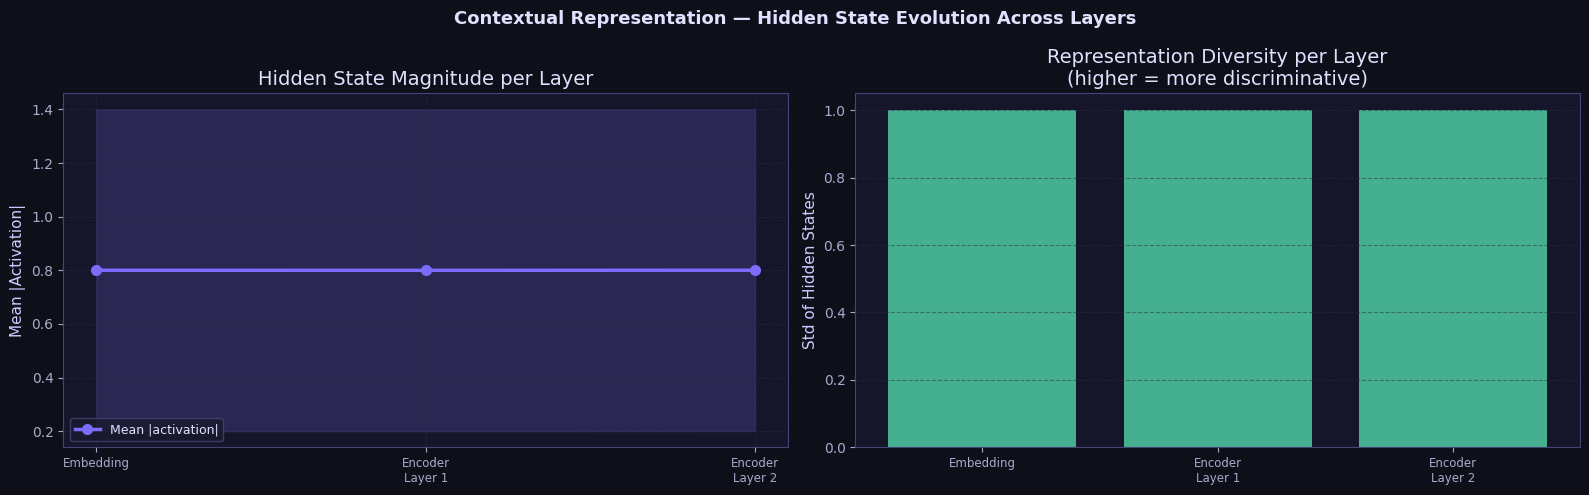

💾 Saved → ..\outputs\figures\N6/hidden_state_evolution.png


In [24]:
# ── Figure 2: Hidden state evolution across encoder layers ────────────────────
if all_hidden:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(
        'Contextual Representation — Hidden State Evolution Across Layers',
        fontsize=13, fontweight='bold', color='#e0e0ff'
    )

    # Layer-wise mean activation magnitude
    ax1 = axes[0]
    means = [h.abs().mean().item() for h in all_hidden]
    stds  = [h.abs().std().item()  for h in all_hidden]
    x     = range(len(means))
    ax1.plot(x, means, color=ACCENT, linewidth=2.5, marker='o',
             markersize=7, label='Mean |activation|')
    ax1.fill_between(
        x,
        [m - s for m, s in zip(means, stds)],
        [m + s for m, s in zip(means, stds)],
        alpha=0.2, color=ACCENT
    )
    ax1.set_xticks(list(x))
    ax1.set_xticklabels(
        ['Embedding'] + [f'Encoder\nLayer {i+1}' for i in range(len(means)-1)],
        fontsize=8.5
    )
    ax1.set_ylabel('Mean |Activation|')
    ax1.set_title('Hidden State Magnitude per Layer')
    ax1.legend(fontsize=9)
    ax1.grid(True)

    # Layer-wise std (diversity of representations)
    ax2 = axes[1]
    stds_all = [h.std().item() for h in all_hidden]
    ax2.bar(list(x), stds_all, color=GREEN, edgecolor='none', alpha=0.85)
    ax2.set_xticks(list(x))
    ax2.set_xticklabels(
        ['Embedding'] + [f'Encoder\nLayer {i+1}' for i in range(len(stds_all)-1)],
        fontsize=8.5
    )
    ax2.set_ylabel('Std of Hidden States')
    ax2.set_title('Representation Diversity per Layer\n'
                  '(higher = more discriminative)')
    ax2.grid(axis='y')

    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / 'hidden_state_evolution.png', dpi=150,
                bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print(f'💾 Saved → {OUTPUT_DIR}/hidden_state_evolution.png')

## 🔬 Step 9 — Compare Embedding vs Contextual Representations

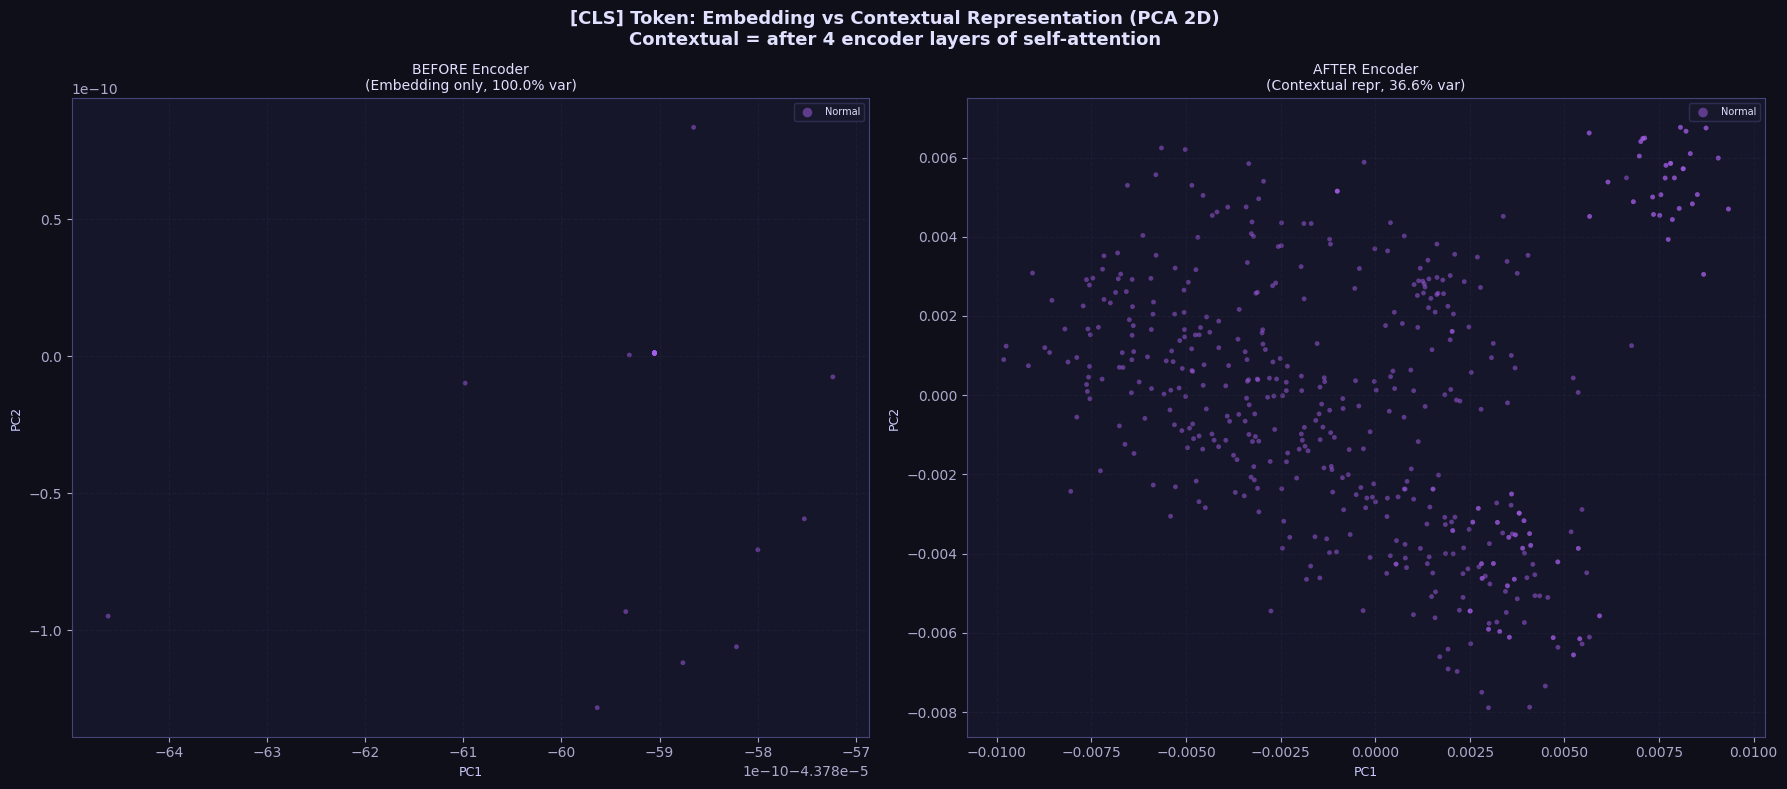

💾 Saved → ..\outputs\figures\N6/contextual_repr_pca.png

💡 After training, post-encoder clusters should be far more separated.


In [25]:
# ── PCA: Embedding (pre-encoder) vs Contextual (post-encoder) ─────────────────
if all_hidden and len(all_hidden) >= 2:
    # Take [CLS] token (position 0) representations
    cls_before = all_hidden[0][:, 0, :].numpy()   # after embedding layer
    cls_after  = all_hidden[-1][:, 0, :].numpy()  # after last encoder layer
    sample_lbl = sample_labels.numpy()

    pca         = PCA(n_components=2, random_state=RANDOM_STATE)
    cls_b_2d    = pca.fit_transform(cls_before)
    var_before  = pca.explained_variance_ratio_.sum()

    pca2        = PCA(n_components=2, random_state=RANDOM_STATE)
    cls_a_2d    = pca2.fit_transform(cls_after)
    var_after   = pca2.explained_variance_ratio_.sum()

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle(
        '[CLS] Token: Embedding vs Contextual Representation (PCA 2D)\n'
        'Contextual = after 4 encoder layers of self-attention',
        fontsize=13, fontweight='bold', color='#e0e0ff'
    )

    for ax, emb_2d, title, var in [
        (axes[0], cls_b_2d,
         f'BEFORE Encoder\n(Embedding only, {var_before*100:.1f}% var)', var_before),
        (axes[1], cls_a_2d,
         f'AFTER Encoder\n(Contextual repr, {var_after*100:.1f}% var)', var_after),
    ]:
        for idx in range(len(label_map)):
            mask = (sample_lbl == idx)
            if mask.sum() == 0:
                continue
            ax.scatter(
                emb_2d[mask, 0], emb_2d[mask, 1],
                c          = PALETTE[idx % len(PALETTE)],
                label      = label_map.get(str(idx), label_map.get(int(idx))),
                alpha      = 0.5, s=12, edgecolors='none'
            )
        ax.set_xlabel('PC1', fontsize=9)
        ax.set_ylabel('PC2', fontsize=9)
        ax.set_title(title, fontsize=10)
        ax.legend(loc='upper right', fontsize=7,
                  markerscale=2, framealpha=0.5)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / 'contextual_repr_pca.png', dpi=150,
                bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print(f'💾 Saved → {OUTPUT_DIR}/contextual_repr_pca.png')
    print(f'\n💡 After training, post-encoder clusters should be far more separated.')

In [26]:
# ── Figure: Attention entropy per layer (how focused vs diffuse) ──────────────
if all_attentions:
    fig, ax = plt.subplots(figsize=(12, 5))

    for layer_idx, layer_attn in enumerate(all_attentions):
        # layer_attn: (batch, heads, seq, seq)
        # Entropy per query position averaged over batch + heads
        attn_probs = layer_attn.float()
        entropy    = -(attn_probs * (attn_probs + 1e-9).log())
        entropy    = entropy.sum(-1)              # (batch, heads, seq)
        avg_entropy= entropy.mean().item()

        ax.bar(
            layer_idx,
            avg_entropy,
            color=PALETTE[layer_idx % len(PALETTE)],
            edgecolor='none', alpha=0.85,
            label=f'Layer {layer_idx+1}'
        )
        ax.text(layer_idx, avg_entropy + 0.01,
                f'{avg_entropy:.3f}',
                ha='center', va='bottom',
                fontsize=10, color='#ccccff')

    ax.set_xticks(range(len(all_attentions)))
    ax.set_xticklabels([f'Encoder\nLayer {i+1}'
                        for i in range(len(all_attentions))], fontsize=9)
    ax.set_ylabel('Average Attention Entropy')
    ax.set_title(
        'Attention Entropy per Encoder Layer\n'
        '(Higher = more diffuse attention | Lower = more focused)',
        fontsize=12
    )
    ax.grid(axis='y')
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / 'attention_entropy.png', dpi=150,
                bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print(f'💾 Saved → {OUTPUT_DIR}/attention_entropy.png')

## 💾 Step 10 — Save Contextual Representations

In [27]:
# ── Save [CLS] contextual embeddings for the sample batch ─────────────────────
torch.save(
    {
        'cls_embeddings'     : pooled_output,    # (N, 128) — post-pooler [CLS]
        'last_hidden_state'  : last_hidden,      # (N, 512, 128) — all tokens
        'logits'             : logits,            # (N, 15) — classification scores
        'labels'             : sample_labels,     # (N,) — ground truth
        'label_map'          : label_map,
        'sample_size'        : SAMPLE_SIZE,
        'hidden_size'        : HIDDEN_SIZE,
        'num_layers'         : NUM_HIDDEN_LAYERS * 2,
    },
    OUTPUT_PATH
)

saved_size_mb = OUTPUT_PATH.stat().st_size / 1e6
print(f'✅ Contextual representations saved.')
print(f'   Path               : {OUTPUT_PATH.resolve()}')
print(f'   Size               : {saved_size_mb:.1f} MB')
print(f'   cls_embeddings     : {tuple(pooled_output.shape)}')
print(f'   last_hidden_state  : {tuple(last_hidden.shape)}')
print(f'   logits             : {tuple(logits.shape)}')

✅ Contextual representations saved.
   Path               : C:\Users\kaush\Desktop\LLM Threat Detection on IIOT\SecurityBERT CLAUDE\data\processed\contextual_repr.pt
   Size               : 152.3 MB
   cls_embeddings     : (512, 128)
   last_hidden_state  : (512, 512, 128)
   logits             : (512, 15)


---
## ✅ Summary — Notebook 06 Outputs

| Artefact | Location |
|----------|----------|
| Contextual representations | `data/processed/contextual_repr.pt` |
| Attention maps (4 heads) | `outputs/figures/attention_maps.png` |
| Hidden state evolution | `outputs/figures/hidden_state_evolution.png` |
| Contextual PCA (before/after) | `outputs/figures/contextual_repr_pca.png` |
| Attention entropy chart | `outputs/figures/attention_entropy.png` |

---

### What This Notebook Implemented

| Component | Paper Reference | Details |
|-----------|----------------|---------|
| Self-Attention | Equation (3) | `Attention(Q,K,V) = σ(QKᵀ/√dₖ)·V` |
| Q/K/V projections | Figure 5 | `Linear(128→128)` each |
| Self Output | Figure 5 | `Linear + Dropout(0.1) + LayerNorm(eps=1e-12)` |
| Intermediate | Figure 5 | `Linear(128→512) + GELU` |
| Encoder Output | Figure 5 | `Linear(512→128) + Dropout(0.1) + LayerNorm` |
| Encoder Stack | Section III-I | 4 stacked BertLayers |
| Scale factor √dₖ | Equation (3) | `√32 = 5.657` |

---

### 🔜 Carry Forward to Notebook 07 — Training SecurityBERT

```python
# Load saved model
ckpt   = torch.load('checkpoints/securitybert_init.pt')
config = BertConfig(**ckpt['config'])
model  = SecurityBERT(config)
model.load_state_dict(ckpt['model_state_dict'])

# Training strategy (Option 3):
#   ✅ Focal Loss         → handles extreme 1,615× imbalance
#   ✅ Class Weights      → computed from class distribution
#   ✅ Stratified Sampler → every batch contains all 15 classes
#
# Paper training config (Table IV):
#   batch_size = 128
#   epochs     = 4
#   hardware   = Nvidia A100 GPU
```